In [3]:
#%pip install optuna

In [1]:
# libraries
import pandas as pd
import numpy as np
import functools as ft
import seaborn as sns
import matplotlib.pyplot as plt
from preprocess_v1 import*
# modelacion
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
import lightgbm as lgb
# encoding
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler

# seleccion de modelos
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
from sklearn.feature_selection import SelectPercentile
import xgboost as xgb
import lightgbm as lgb
import optuna
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    roc_auc_score
)
from sklearn.feature_selection import (
    SelectKBest, f_classif, chi2, mutual_info_classif,
    RFE, SelectFromModel, VarianceThreshold
)
# Review models
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.metrics import precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
#otros
import time
import warnings
warnings.filterwarnings('ignore')

## Carga de datos

In [2]:
dt_merge = pd.read_csv("/home/estebanm/Escritorio/docs_tfm/Datos_desde_audios_varias_fuentes/merge_variables/audio_features.csv")
dt_merge.head()

,name,duracion_s,rms_mean,rms_std,sujeto,dementia,dementia type,gender,ethnicity,datasplit,...,syntax_depth,std_words_per_sent,mean_word_length,std_word_length,function_ratio,transcript,duration,pause_prob,language,wpm
0,Abe Burrows,71.019688,0.071390,0.050389,abeburrows,1,Alzheimer,male,Caucasian/White,train,...,7.666667,75.330383,3.789030,2.132184,0.611814,to me Bob was he was worried when I became a p...,72.76,0.263634,en,195.437053
1,Aileen Hernandez,47.000000,0.144582,0.090372,aileenhernandez,1,Dementia,female,Black/African American,train,...,5.500000,13.379088,3.810811,1.850315,0.628378,This is not going to sound like very ladylike....,47.04,0.122493,en,188.775510
2,Aileen Hernandez,38.000000,0.123960,0.079574,aileenhernandez,1,Dementia,female,Black/African American,train,...,5.428571,12.290697,3.625000,1.952562,0.585938,I arrive at my first political science class. ...,38.40,0.000328,en,200.000000
3,Aileen Hernandez,90.000000,0.061281,0.049997,aileenhernandez,1,Dementia,female,Black/African American,train,...,5.357143,9.598044,4.003597,2.092292,0.575540,We are more conscious in this state now about ...,89.00,0.002673,en,187.415730
4,Alan Ramsey,55.000000,0.060310,0.051383,alanramsey,1,Dementia,male,Caucasian/White,train,...,4.500000,8.890444,4.286585,2.216252,0.640244,"I'm pretty jaundiced one, Virginia, I have to ...",55.00,0.149834,en,178.909091


In [3]:
# sacar variables que no son parte del analisis
dt_merge.drop(['language', 'transcript', 'audio_file', 'datasplit', 'sujeto', 'name', 'dementia type'], axis=1, inplace=True)


## Preprocesamiento

### Imputaciones

In [4]:
dt_merge.dementia.value_counts(normalize=True)

dementia
0    0.628895
1    0.371105
Name: proportion, dtype: float64

In [5]:
dt_merge = categorical_imputation(dt_merge)

gender: Moda = 'male' (137 nulos a reemplazar)
ethnicity: Moda = 'Caucasian/White' (137 nulos a reemplazar)
gender: 137→ 0 nulos 
ethnicity: 137→ 0 nulos 


In [6]:
dt_merge['std_word_length'] = numeric_imputation(dt_merge, 'std_word_length')


In [7]:
dt_merge['function_ratio'] = numeric_imputation(dt_merge, 'function_ratio')

In [8]:
dt_merge.isnull().sum()

duracion_s         0
rms_mean           0
rms_std            0
dementia           0
gender             0
                  ..
std_word_length    0
function_ratio     0
duration           0
pause_prob         0
wpm                0
Length: 73, dtype: int64

### Transformaciones

In [9]:
#crear y ajustar el encoder
label_encoder = LabelEncoder()
dt_merge['gender'] = label_encoder.fit_transform(dt_merge['gender'])
dt_merge['ethnicity'] = label_encoder.fit_transform(dt_merge['ethnicity'])

In [10]:
dt_merge.gender.value_counts()

gender
1    322
0     31
Name: count, dtype: int64

In [26]:
#  Separar las variables X & y
X = dt_merge.drop('dementia', axis=1)
y = dt_merge['dementia']

print(f"\nX shape:{X.shape}")
print(f"\ny shape:{y.shape}")
print(f"n Distribucion de clases:")
print(y.value_counts(normalize=True))


X shape:(335, 72)

y shape:(335,)
n Distribucion de clases:
dementia
0.0    0.635821
1.0    0.364179
Name: proportion, dtype: float64


### Standarizacion

In [39]:
Xnew = X.dropna()

In [40]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(Xnew)


In [41]:
X_scaled.shape

(335, 72)

In [42]:
Xnew.shape

(335, 72)

## Modelacion

### PCA

In [43]:
# Perform PCA without specifying n_components
pca = PCA()
pca.fit(X_scaled)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


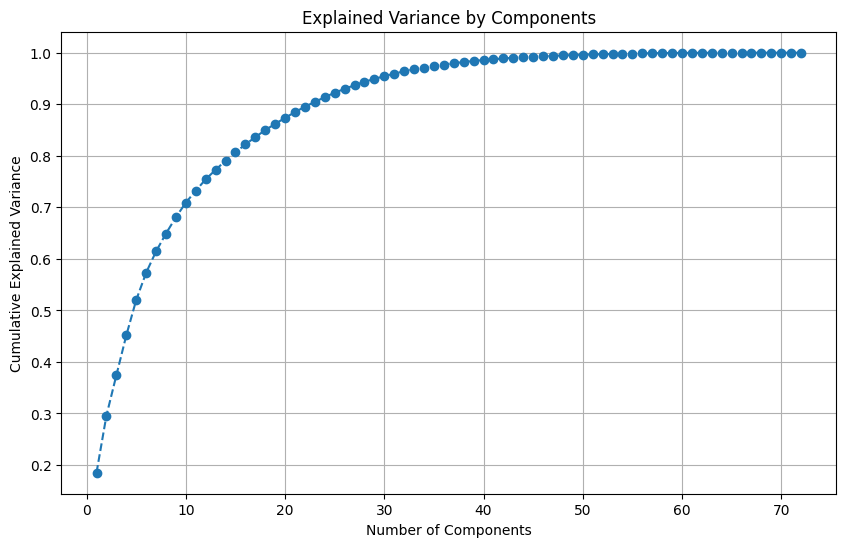

In [44]:
# Plot the explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Components')
plt.grid(True)
plt.show()

In [52]:
pca = PCA(n_components=0.80)  # Retain 90% of variance
X_pca = pca.fit(X_scaled)

optimal_components = pca.n_components_
print(f"Optimal Number of Components: {optimal_components}")

Optimal Number of Components: 15


In [53]:
explained_variance_ratio = pca.explained_variance_ratio_.cumsum()
optimal_components = (explained_variance_ratio < 0.80).sum() + 1  # 95% variance
print(f"Selected Components (95% Variance): {optimal_components}")

pca = PCA(n_components=optimal_components)
X_pca = pca.fit_transform(X_scaled)


for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"Component {i+1}: {var*100:.2f}%")

# Apply PCA for dimensionality reduction
#pca = PCA(n_components=8)  # Keep 95% of the variance
#X_pca = pca.fit_transform(X_scaled)
#print(f"Original shape: {X_scaled.shape}, PCA shape: {X_pca.shape}")


Selected Components (95% Variance): 15
Component 1: 18.50%
Component 2: 11.08%
Component 3: 7.82%
Component 4: 7.73%
Component 5: 6.87%
Component 6: 5.30%
Component 7: 4.13%
Component 8: 3.47%
Component 9: 3.15%
Component 10: 2.84%
Component 11: 2.30%
Component 12: 2.22%
Component 13: 1.84%
Component 14: 1.78%
Component 15: 1.61%


### Modelo

In [54]:
X_pca.shape

(335, 15)

In [55]:
y.shape

(335,)

In [56]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42, )

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((234, 15), (101, 15), (234,), (101,))

In [57]:
# LBG MODEL

def train_and_evaluate(X_train, y_train, X_test, y_test):
    # Handle class imbalance using SMOTE
    smote = SMOTE(sampling_strategy='auto', random_state=42)  # Over-sample to balance classes- 0.8--0.9+, auto--=  0.438
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    # Calculate scale_pos_weight for LightGBM
    pos_weight = len(y_train_resampled[y_train_resampled == 0]) / len(y_train_resampled[y_train_resampled == 1])

    # Objective function for Optuna
    def objective(trial):
        boosting_type = trial.suggest_categorical("boosting_type", ["gbdt", "goss"])
        learning_rate = trial.suggest_float("learning_rate", 0.01,  0.1, log=True) # 0.05, 0.1
        num_leaves = trial.suggest_int("num_leaves", 20, 150) # 31, 150
        max_depth = trial.suggest_int("max_depth", 5, 20) # -1, 15
        min_child_samples = trial.suggest_int("min_child_samples", 5, 50) # 5, 100
        min_child_weight = trial.suggest_float("min_child_weight", 1e-3, 10.0, log=True)
        subsample = trial.suggest_float("subsample", 0.5, 1.0) if boosting_type == "gbdt" else 1.0
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0) # 0.6
        reg_alpha = trial.suggest_float("reg_alpha", 1e-3, 100.0, log=True) # 1e-3
        reg_lambda = trial.suggest_float("reg_lambda", 1e-3, 100.0, log=True) # 1e-3
        n_estimators = trial.suggest_int("n_estimators", 50, 500) #500

        params = {
            "boosting_type": boosting_type,
            "learning_rate": learning_rate,
            "num_leaves": num_leaves,
            "max_depth": max_depth,
            "min_child_samples": min_child_samples,
            "min_child_weight": min_child_weight,
            "subsample": subsample,
            "colsample_bytree": colsample_bytree,
            "reg_alpha": reg_alpha,
            "reg_lambda": reg_lambda,
            "scale_pos_weight": pos_weight,
            "n_estimators": n_estimators,
        }

        train_data = lgb.Dataset(X_train_resampled, label=y_train_resampled)
        valid_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

        model = lgb.train(
            params,
            train_data,
            valid_sets=[valid_data],
            callbacks=[lgb.early_stopping(stopping_rounds=10)],
        )

        y_probs = model.predict(X_test)
        return recall_score(y_test, (y_probs >= 0.5).astype(int))  # Optimize for recall =0.5

    # Optuna hyperparameter tuning
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=20)

    best_params = study.best_params
    print("Best Parameters:", best_params)

    # Train final model with best parameters
    best_params['is_unbalance'] = True
    best_model = lgb.LGBMClassifier(random_state=42, **best_params)  # objective = 'binary'
    best_model.fit(X_train_resampled, y_train_resampled, eval_metric='auc')

    # Optimize threshold using F-beta score (recall-prioritized)
    y_probs = best_model.predict_proba(X_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
    fbeta_scores = (2 * precision * recall) / (precision + recall + 1e-9)  # Beta = 2 (recall-prioritized)
    optimal_idx = np.argmax(fbeta_scores)
    optimal_threshold = thresholds[optimal_idx]

    # Predictions and metrics
    y_pred = (y_probs >= optimal_threshold).astype(int)
    metrics = {
        "ROC-AUC": roc_auc_score(y_test, y_probs),
        "F1-score": f1_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred),
        #"MCC": matthews_corrcoef(y_test, y_pred),
       #"Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    }

    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")

    return best_model, optimal_threshold, metrics


# Training and evaluation function remains the same
best_model, optimal_threshold, metrics = train_and_evaluate(X_train, y_train, X_test, y_test)

[I 2026-01-26 21:27:42,112] A new study created in memory with name: no-name-ffa0f6ac-c733-4fdf-b12f-4b0425427cac
[I 2026-01-26 21:27:42,182] Trial 0 finished with value: 0.47619047619047616 and parameters: {'boosting_type': 'gbdt', 'learning_rate': 0.029702938199449334, 'num_leaves': 62, 'max_depth': 14, 'min_child_samples': 47, 'min_child_weight': 0.013012316063888333, 'subsample': 0.7112629330763701, 'colsample_bytree': 0.5567135020707228, 'reg_alpha': 4.6615443320871135, 'reg_lambda': 3.083163889523518, 'n_estimators': 443}. Best is trial 0 with value: 0.47619047619047616.
[I 2026-01-26 21:27:42,276] Trial 1 finished with value: 0.5476190476190477 and parameters: {'boosting_type': 'goss', 'learning_rate': 0.01993979608886675, 'num_leaves': 96, 'max_depth': 13, 'min_child_samples': 47, 'min_child_weight': 2.943632755710179, 'colsample_bytree': 0.7425700427038493, 'reg_alpha': 8.37697010895958, 'reg_lambda': 47.92621197957041, 'n_estimators': 171}. Best is trial 1 with value: 0.54761

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000593 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1555
[LightGBM] [Info] Number of data points in the train set: 308, number of used features: 15
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 10 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

[I 2026-01-26 21:27:42,399] Trial 2 finished with value: 0.5 and parameters: {'boosting_type': 'gbdt', 'learning_rate': 0.01445266978518911, 'num_leaves': 105, 'max_depth': 16, 'min_child_samples': 46, 'min_child_weight': 0.006118832354327473, 'subsample': 0.826258601127859, 'colsample_bytree': 0.5680377003153254, 'reg_alpha': 0.005282090026871893, 'reg_lambda': 5.423993867251111, 'n_estimators': 440}. Best is trial 1 with value: 0.5476190476190477.
[I 2026-01-26 21:27:42,416] Trial 3 finished with value: 1.0 and parameters: {'boosting_type': 'goss', 'learning_rate': 0.01620163126536154, 'num_leaves': 77, 'max_depth': 5, 'min_child_samples': 9, 'min_child_weight': 8.793000969559404, 'colsample_bytree': 0.9884469699040385, 'reg_alpha': 64.68878533990897, 'reg_lambda': 0.13419612618335247, 'n_estimators': 243}. Best is trial 3 with value: 1.0.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-01-26 21:27:42,525] Trial 4 finished with value: 0.47619047619047616 and parameters: {'boosting_type': 'gbdt', 'learning_rate': 0.030663118691783765, 'num_leaves': 58, 'max_depth': 20, 'min_child_samples': 34, 'min_child_weight': 0.1442937592886936, 'subsample': 0.8636480985575847, 'colsample_bytree': 0.869843358560576, 'reg_alpha': 0.04249838942742787, 'reg_lambda': 0.09759694362052079, 'n_estimators': 409}. Best is trial 3 with value: 1.0.
[I 2026-01-26 21:27:42,627] Trial 5 finished with value: 0.5476190476190477 and parameters: {'boosting_type': 'goss', 'learning_rate': 0.01875408443269488, 'num_leaves': 142, 'max_depth': 12, 'min_child_samples': 32, 'min_child_weight': 0.001700893385338341, 'colsample_bytree': 0.5145238174263701, 'reg_alpha': 5.659810632669237, 'reg_lambda': 0.09998447611199272, 'n_estimators': 251}. Best is trial 3 with value: 1.0.


[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000412 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1555
[LightGBM] [Info] Number of data points in the train set: 308, number of used features: 15
[LightGBM] [Info] Using GOSS
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Start training from score 0

[I 2026-01-26 21:27:42,879] Trial 6 finished with value: 0.47619047619047616 and parameters: {'boosting_type': 'gbdt', 'learning_rate': 0.01300970102631396, 'num_leaves': 121, 'max_depth': 11, 'min_child_samples': 14, 'min_child_weight': 0.006857956766434373, 'subsample': 0.6938322986184544, 'colsample_bytree': 0.6792913843203198, 'reg_alpha': 0.13823678761424846, 'reg_lambda': 1.2366422825087993, 'n_estimators': 57}. Best is trial 3 with value: 1.0.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-01-26 21:27:43,053] Trial 7 finished with value: 0.5 and parameters: {'boosting_type': 'goss', 'learning_rate': 0.026450935066265994, 'num_leaves': 115, 'max_depth': 18, 'min_child_samples': 20, 'min_child_weight': 4.771874491263001, 'colsample_bytree': 0.9322631143355508, 'reg_alpha': 3.5785144016473645, 'reg_lambda': 1.0776731289343957, 'n_estimators': 500}. Best is trial 3 with value: 1.0.
[I 2026-01-26 21:27:43,062] Trial 8 finished with value: 1.0 and parameters: {'boosting_type': 'gbdt', 'learning_rate': 0.02882401833252048, 'num_leaves': 117, 'max_depth': 15, 'min_child_samples': 20, 'min_child_weight': 0.0012039889398390703, 'subsample': 0.7917381532889861, 'colsample_bytree': 0.5919113993478937, 'reg_alpha': 40.63937469464361, 'reg_lambda': 0.018388543645365813, 'n_estimators': 447}. Best is trial 3 with value: 1.0.
[I 2026-01-26 21:27:43,073] Trial 9 finished with value: 1.0 and parameters: {'boosting_type': 'goss', 'learning_rate': 0.010036233300488147, 'num_leaves':

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-01-26 21:27:43,264] Trial 12 finished with value: 0.5238095238095238 and parameters: {'boosting_type': 'goss', 'learning_rate': 0.043172870274548754, 'num_leaves': 141, 'max_depth': 8, 'min_child_samples': 15, 'min_child_weight': 0.4598707818989192, 'colsample_bytree': 0.6714416568499681, 'reg_alpha': 1.4093659275813608, 'reg_lambda': 0.025169283369665556, 'n_estimators': 157}. Best is trial 3 with value: 1.0.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-01-26 21:27:43,413] Trial 13 finished with value: 0.47619047619047616 and parameters: {'boosting_type': 'gbdt', 'learning_rate': 0.08133374950149458, 'num_leaves': 83, 'max_depth': 15, 'min_child_samples': 14, 'min_child_weight': 0.0014354432094658136, 'subsample': 0.990678210099113, 'colsample_bytree': 0.7966391591142746, 'reg_alpha': 0.49709868336841934, 'reg_lambda': 0.014336633453327337, 'n_estimators': 342}. Best is trial 3 with value: 1.0.
[I 2026-01-26 21:27:43,427] Trial 14 finished with value: 1.0 and parameters: {'boosting_type': 'goss', 'learning_rate': 0.02040925900727304, 'num_leaves': 23, 'max_depth': 10, 'min_child_samples': 26, 'min_child_weight': 0.03556889301579452, 'colsample_bytree': 0.6865003399205113, 'reg_alpha': 29.11514621812005, 'reg_lambda': 0.14599152460047182, 'n_estimators': 209}. Best is trial 3 with value: 1.0.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[19]	valid_0's l2: 0.235381
[LightGBM] [Warning] Found boosting=g

[I 2026-01-26 21:27:43,565] Trial 15 finished with value: 0.5714285714285714 and parameters: {'boosting_type': 'gbdt', 'learning_rate': 0.036591457577195445, 'num_leaves': 127, 'max_depth': 17, 'min_child_samples': 10, 'min_child_weight': 9.105865508882495, 'subsample': 0.5837190568966157, 'colsample_bytree': 0.8971730363013513, 'reg_alpha': 0.002001732337515979, 'reg_lambda': 0.0010520089097103176, 'n_estimators': 351}. Best is trial 3 with value: 1.0.
[I 2026-01-26 21:27:43,578] Trial 16 finished with value: 1.0 and parameters: {'boosting_type': 'gbdt', 'learning_rate': 0.023602459227104942, 'num_leaves': 94, 'max_depth': 7, 'min_child_samples': 19, 'min_child_weight': 0.9151618214639096, 'subsample': 0.9617477633572944, 'colsample_bytree': 0.9963172047100716, 'reg_alpha': 28.339619200664586, 'reg_lambda': 0.03360517251982684, 'n_estimators': 80}. Best is trial 3 with value: 1.0.
[I 2026-01-26 21:27:43,655] Trial 17 finished with value: 0.5476190476190477 and parameters: {'boosting_t

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[19]	valid_0's l2: 0.231047
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000179 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1555
[LightGBM] [Info] Number of data points in the train set: 308, number of used features: 15
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves t

[I 2026-01-26 21:27:44,166] Trial 18 finished with value: 0.4523809523809524 and parameters: {'boosting_type': 'goss', 'learning_rate': 0.010313552827754325, 'num_leaves': 73, 'max_depth': 13, 'min_child_samples': 11, 'min_child_weight': 0.038087794621315015, 'colsample_bytree': 0.7499231178838475, 'reg_alpha': 0.09751356507259933, 'reg_lambda': 0.42583351442819656, 'n_estimators': 142}. Best is trial 3 with value: 1.0.
[I 2026-01-26 21:27:44,271] Trial 19 finished with value: 0.5476190476190477 and parameters: {'boosting_type': 'gbdt', 'learning_rate': 0.03782846807079929, 'num_leaves': 106, 'max_depth': 18, 'min_child_samples': 19, 'min_child_weight': 0.003347749532965172, 'subsample': 0.8102616420862074, 'colsample_bytree': 0.8020440505969135, 'reg_alpha': 0.02573824478939658, 'reg_lambda': 0.40511216790242205, 'n_estimators': 365}. Best is trial 3 with value: 1.0.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[95]	valid_0's l2: 0.236048
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001928 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1555
[LightGBM] [Info] Number of data points in the train set: 308, number of used features: 15
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 10 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] 